# TP1 - Estudio de potenciales y campos eléctricos
**Materia:** Electricidad y Magnetismo

**Integrantes:** 
Fernanda Perez

**Fecha:**
20/08/2026

## Objetivo

Determinar las líneas equipotenciales y las líneas de campo eléctrico generadas por distintas configuraciones de electrodos sumergidos en agua, midiendo el potencial con un voltímetro.

## Materiales y montaje

*Bandeja de vidrio de borosilicato con agua, papel milimetrado, placas metalicas, fuente de 10V, multimetro*

## 1. Carga de datos

Cada línea equipotencial es un conjunto de puntos $(x,y)$ donde el voltímetro midió el mismo potencial $V$.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import splprep, splev, griddata

In [2]:
# Mediciones reales - configuración de placas paralelas
lineas_equipotenciales = {
    2.0: [(3.5, 5), (3.5, 3), (3.5, 7.3), (3.5, 9.8), (3.5, 11.5),
          (3.5, 14), (3.5, 15.5), (3.5, 17.5)],
    3.0: [(5.5, 0.5), (5.5, 2), (5.5, 4), (5.5, 6.4), (5.5, 8.5),
          (5.5, 10), (6.0, 12.5), (6.0, 16.2)],
    4.0: [(7.8, 1), (8.0, 3), (8.0, 5), (7.9, 6.5), (8.0, 8.5),
          (8.0, 11), (8.2, 14), (8.0, 17)],
    5.0: [(11.5, 10), (11.4, 11.5), (11.5, 15.5), (11.5, 7.5),
          (11.5, 6), (11.5, 4.5), (11.5, 2)],
    7.0: [(15.5, 2), (15.5, 4.3), (15.5, 6.8), (15.5, 9.2), (15.4, 11.7),
          (15.8, 13.9), (15.6, 16.8), (16.0, 18)],
    8.0: [(18, 2), (18, 4), (18, 5.5), (18.5, 9), (18.5, 10),
          (18, 12), (18.5, 13.6), (18.5, 16)],
}

electrodo_positivo = (20, 9)   # placa a 20 cm, mayor potencial
electrodo_negativo = (0, 9)    # placa en x=0, menor potencial

## 2. Gráfico de líneas equipotenciales

Cada línea se grafica con un color distinto, uniendo los puntos medidos con una curva suave (spline).

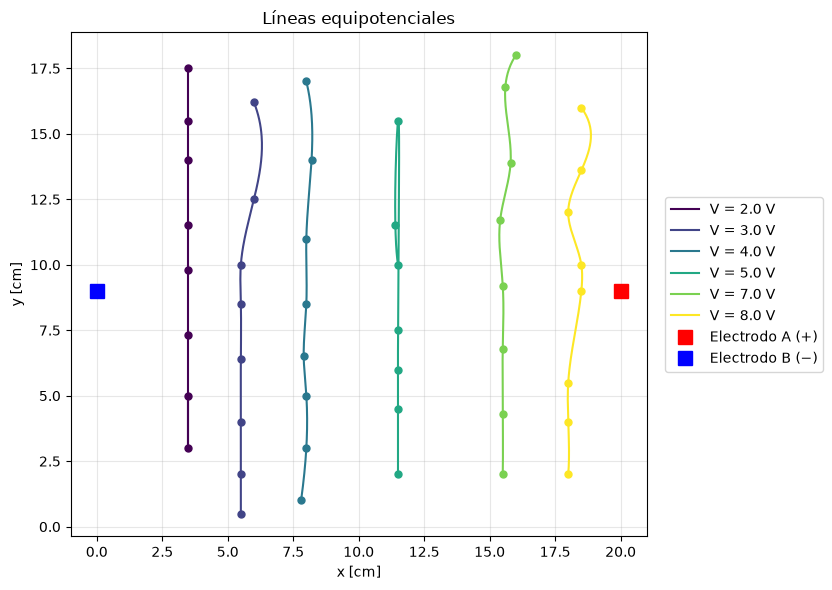

In [3]:
fig, ax = plt.subplots(figsize=(8, 6))

colores = plt.cm.viridis(np.linspace(0, 1, len(lineas_equipotenciales)))

for (voltaje, puntos), color in zip(sorted(lineas_equipotenciales.items()), colores):
    puntos = np.array(puntos)
    x = puntos[:, 0]
    y = puntos[:, 1]

    ax.plot(x, y, "o", color=color, markersize=5)

    if len(x) >= 4:
        tck, _ = splprep([x, y], s=0)
        x_suave, y_suave = splev(np.linspace(0, 1, 200), tck)
        ax.plot(x_suave, y_suave, "-", color=color, linewidth=1.5,
                 label=f"V = {voltaje} V")
    else:
        ax.plot(x, y, "-", color=color, linewidth=1.5,
                 label=f"V = {voltaje} V")

ax.plot(*electrodo_positivo, "s", color="red", markersize=10, label="Electrodo A (+)")
ax.plot(*electrodo_negativo, "s", color="blue", markersize=10, label="Electrodo B (−)")

ax.set_xlabel("x [cm]")
ax.set_ylabel("y [cm]")
ax.set_title("Líneas equipotenciales")
ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5))
ax.set_aspect("equal")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("lineas_equipotenciales.png", dpi=200)
plt.show()

## 3. Líneas de campo eléctrico (calculadas)

A partir de los puntos medidos se interpola un mapa continuo de potencial $V(x,y)$, y se calcula el campo eléctrico como $\vec{E} = -\nabla V$. Las líneas de campo se trazan automáticamente con `streamplot`, superpuestas a las equipotenciales medidas.

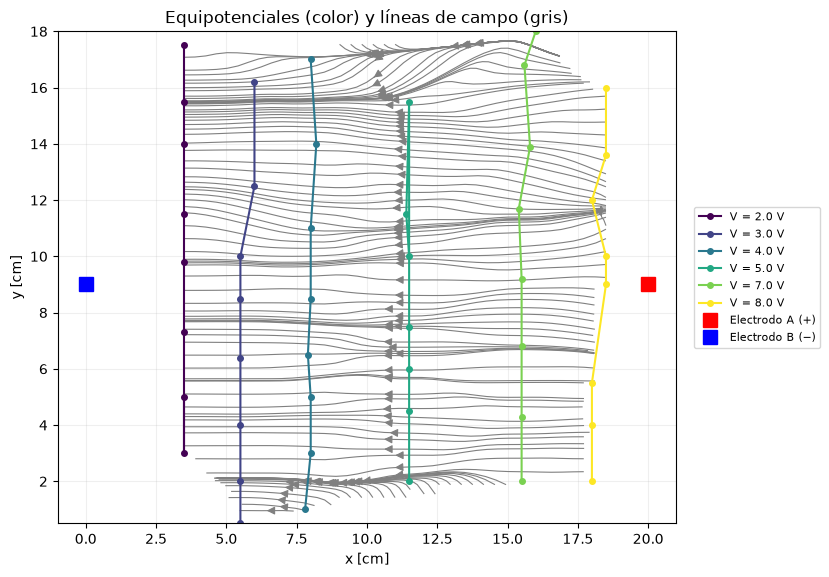

In [4]:
# Reunir todos los puntos medidos (x, y) junto con su potencial
puntos = []
valores = []
for v, pts in lineas_equipotenciales.items():
    for (x, y) in pts:
        puntos.append((x, y))
        valores.append(v)

puntos = np.array(puntos)
valores = np.array(valores)

# Grilla regular para interpolar el potencial
xi = np.linspace(puntos[:, 0].min(), puntos[:, 0].max(), 120)
yi = np.linspace(puntos[:, 1].min(), puntos[:, 1].max(), 120)
Xi, Yi = np.meshgrid(xi, yi)

# Interpolación del potencial sobre la grilla (cubic da curvas más suaves)
Vi = griddata(puntos, valores, (Xi, Yi), method="cubic")

# Campo eléctrico: E = -grad(V)
dVy, dVx = np.gradient(Vi, yi, xi)
Ex, Ey = -dVx, -dVy

# --- Gráfico final: equipotenciales + líneas de campo ---
fig, ax = plt.subplots(figsize=(8, 6))

# Líneas de campo (perpendiculares a las equipotenciales, van de + a -)
ax.streamplot(Xi, Yi, Ex, Ey, color="gray", density=1.3, linewidth=0.8,
              arrowsize=1.2, broken_streamlines=False)

# Equipotenciales medidas, superpuestas
colores = plt.cm.viridis(np.linspace(0, 1, len(lineas_equipotenciales)))
for (voltaje, pts), color in zip(sorted(lineas_equipotenciales.items()), colores):
    pts = np.array(pts)
    ax.plot(pts[:, 0], pts[:, 1], "o-", color=color, markersize=4,
            linewidth=1.5, label=f"V = {voltaje} V")

ax.plot(*electrodo_positivo, "s", color="red", markersize=10, label="Electrodo A (+)")
ax.plot(*electrodo_negativo, "s", color="blue", markersize=10, label="Electrodo B (−)")

ax.set_xlabel("x [cm]")
ax.set_ylabel("y [cm]")
ax.set_title("Equipotenciales (color) y líneas de campo (gris)")
ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), fontsize=8)
ax.set_aspect("equal")
ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig("equipotenciales_y_campo.png", dpi=200)
plt.show()

## 4. Configuración de placas perpendiculares (en L)

Se repite el mismo análisis con la segunda configuración medida: dos placas perpendiculares entre sí, formando una "L".

In [5]:
# Mediciones reales - configuración de placa en L (una sola placa doblada,
# un tramo horizontal arriba y uno vertical a la derecha, unidos en la esquina)
lineas_equipotenciales_L = {
    2.0: [(24.5, 14), (24.0, 11), (24.0, 7.5), (24.5, 5.5),
          (23.5, 4), (23.5, 3), (23.4, 1.5), (24.0, 0)],
    3.0: [(24.0, 13.5), (23.5, 11.5), (22.5, 9), (22.5, 7),
          (21.8, 4.5), (21.5, 3), (21.5, 2), (21.5, 1)],
    4.0: [(19.3, 1.5), (19.5, 4), (20.0, 5), (20.0, 6.9),
          (20.5, 7), (21.5, 9.5), (22.5, 11.5), (23.4, 13)],
    5.0: [(17.0, 0), (16.5, 2), (17.2, 4), (17.5, 5.5),
          (18.5, 8), (17.0, 12), (23.5, 13.5), (23.2, 13.3)],
    7.0: [(9.5, 2), (9.5, 0.5), (13.0, 8), (15.5, 10),
          (19.0, 12.5), (21.5, 13), (22.5, 13.5), (23.3, 14)],
    8.0: [(20.4, 13.5), (22.0, 14), (23.0, 14.5), (14.5, 13),
          (16.0, 12), (10.5, 13), (10.0, 8.5), (7.2, 7)],
}


# Son las mismas dos placas del ensayo anterior (positiva y negativa),
# ahora dispuestas perpendiculares entre sí (no tocándose), en vez de paralelas.
# Ajustar con las medidas reales de la bandeja si las tenés anotadas:
placa_positiva_L = [(5, 15), (25, 15)]   # tramo horizontal, arriba (mayor potencial)
placa_negativa_L = [(25, 0), (25, 13)]   # tramo vertical, a la derecha (menor potencial)

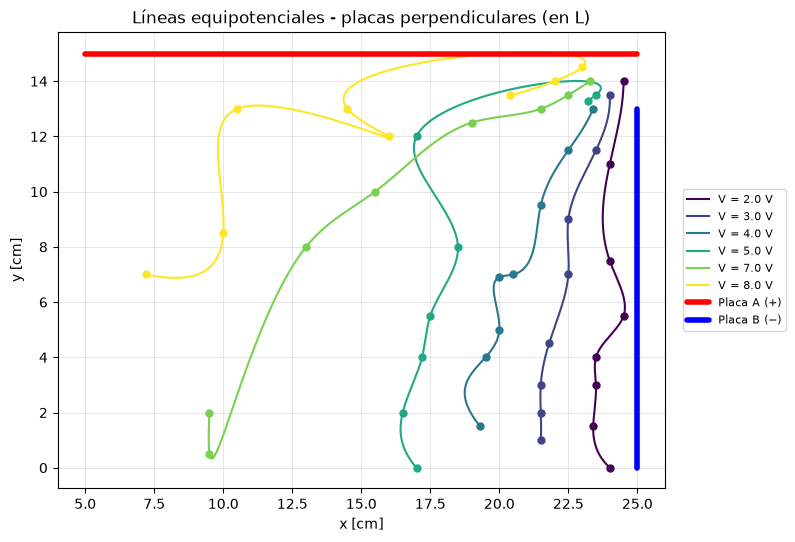

In [6]:
fig, ax = plt.subplots(figsize=(8, 6))

colores_L = plt.cm.viridis(np.linspace(0, 1, len(lineas_equipotenciales_L)))

for (voltaje, pts), color in zip(sorted(lineas_equipotenciales_L.items()), colores_L):
    pts = np.array(pts)
    x, y = pts[:, 0], pts[:, 1]
    ax.plot(x, y, "o", color=color, markersize=5)

    if len(x) >= 4:
        tck, _ = splprep([x, y], s=0)
        x_suave, y_suave = splev(np.linspace(0, 1, 200), tck)
        ax.plot(x_suave, y_suave, "-", color=color, linewidth=1.5, label=f"V = {voltaje} V")
    else:
        ax.plot(x, y, "-", color=color, linewidth=1.5, label=f"V = {voltaje} V")

# Las dos placas, perpendiculares y separadas
px, py = zip(*placa_positiva_L)
nx, ny = zip(*placa_negativa_L)
ax.plot(px, py, color="red", linewidth=4, solid_capstyle="round", label="Placa A (+)")
ax.plot(nx, ny, color="blue", linewidth=4, solid_capstyle="round", label="Placa B (−)")

ax.set_xlabel("x [cm]")
ax.set_ylabel("y [cm]")
ax.set_title("Líneas equipotenciales - placas perpendiculares (en L)")
ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), fontsize=8)
ax.set_aspect("equal")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("equipotenciales_L.png", dpi=200)
plt.show()

### Líneas de campo eléctrico (calculadas) - configuración en L

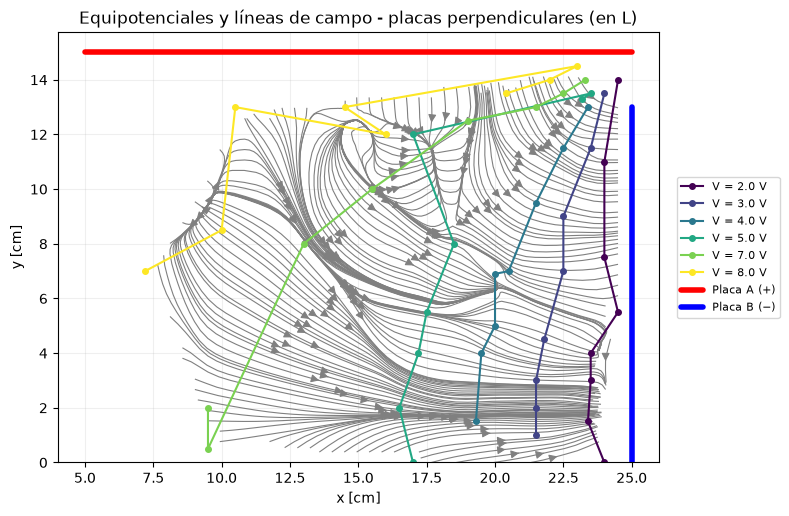

In [7]:
puntos_L = []
valores_L = []
for v, pts in lineas_equipotenciales_L.items():
    for (x, y) in pts:
        puntos_L.append((x, y))
        valores_L.append(v)

puntos_L = np.array(puntos_L)
valores_L = np.array(valores_L)

xi_L = np.linspace(puntos_L[:, 0].min(), puntos_L[:, 0].max(), 120)
yi_L = np.linspace(puntos_L[:, 1].min(), puntos_L[:, 1].max(), 120)
Xi_L, Yi_L = np.meshgrid(xi_L, yi_L)

Vi_L = griddata(puntos_L, valores_L, (Xi_L, Yi_L), method="cubic")

dVy_L, dVx_L = np.gradient(Vi_L, yi_L, xi_L)
Ex_L, Ey_L = -dVx_L, -dVy_L

fig, ax = plt.subplots(figsize=(8, 6))

ax.streamplot(Xi_L, Yi_L, Ex_L, Ey_L, color="gray", density=1.3, linewidth=0.8,
              arrowsize=1.2, broken_streamlines=False)

for (voltaje, pts), color in zip(sorted(lineas_equipotenciales_L.items()), colores_L):
    pts = np.array(pts)
    ax.plot(pts[:, 0], pts[:, 1], "o-", color=color, markersize=4,
            linewidth=1.5, label=f"V = {voltaje} V")

px, py = zip(*placa_positiva_L)
nx, ny = zip(*placa_negativa_L)
ax.plot(px, py, color="red", linewidth=4, solid_capstyle="round", label="Placa A (+)")
ax.plot(nx, ny, color="blue", linewidth=4, solid_capstyle="round", label="Placa B (−)")

ax.set_xlabel("x [cm]")
ax.set_ylabel("y [cm]")
ax.set_title("Equipotenciales y líneas de campo - placas perpendiculares (en L)")
ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), fontsize=8)
ax.set_aspect("equal")
ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig("equipotenciales_y_campo_L.png", dpi=200)
plt.show()

## 4. Análisis y conclusiones

